#Assignment : 8
#Building a Variational Autoencoder and Visualising Its Latent Space




#1. Importing Libraries :

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


#2. Loading the MNIST dataset :  

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


#3. Dataset Preparation :

In [ ]:
# Normalize MNIST pixel values correctly

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
if x_train.ndim == 3:
    x_train = np.expand_dims(x_train, axis=-1)

if x_test.ndim == 3:
    x_test = np.expand_dims(x_test, axis=-1)

# Verify
print("x_train minimum:", np.min(x_train))
print("x_train maximum:", np.max(x_train))
print("x_test minimum:", np.min(x_test))
print("x_test maximum:", np.max(x_test))
print("Data type:", x_train.dtype)
print("Shape:", x_train.shape)

x_train minimum: 0.0
x_train maximum: 1.0
x_test minimum: 0.0
x_test maximum: 1.0
Data type: float32
Shape: (60000, 28, 28, 1)


#4. Displaying The Dataset :

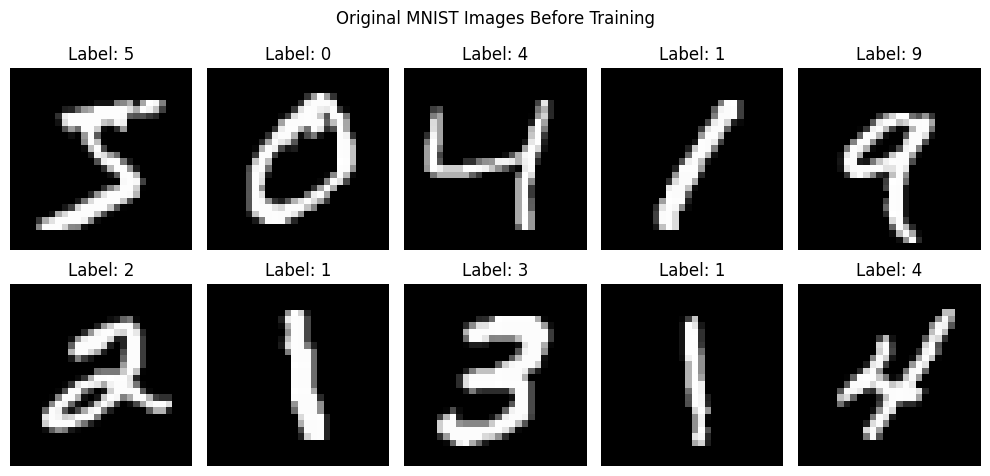

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Original MNIST Images Before Training")
plt.tight_layout()
plt.show()

#5. Buliding a Simple AutoEncoder :

In [ ]:
# Latent dimension
latent_dim = 2

# -------------------------
# ENCODER
# -------------------------
encoder_input = keras.Input(
    shape=(28, 28, 1),
    name="encoder_input"
)

x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

latent = layers.Dense(
    latent_dim,
    activation="sigmoid",
    name="latent_space"
)(x)

encoder = keras.Model(
    encoder_input,
    latent,
    name="encoder"
)


# -------------------------
# DECODER
# -------------------------
decoder_input = keras.Input(
    shape=(latent_dim,),
    name="decoder_input"
)

x = layers.Dense(64, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)

x = layers.Dense(
    28 * 28,
    activation="sigmoid"
)(x)

decoder_output = layers.Reshape(
    (28, 28, 1)
)(x)

decoder = keras.Model(
    decoder_input,
    decoder_output,
    name="decoder"
)


# -------------------------
# AUTOENCODER
# -------------------------
autoencoder_input = keras.Input(
    shape=(28, 28, 1)
)

encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(
    autoencoder_input,
    decoded,
    name="simple_autoencoder"
)

autoencoder.summary()

Model: "simple_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       108,866 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       109,648 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,514 (853.57 KB)

 Trainable params: 218,514 (853.57 KB)

 Non-trainable params: 0 (0.00 B)

#6. Compile the Autoencoder :

In [ ]:

reconstruction_loss = keras.losses.BinaryCrossentropy()

autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss=reconstruction_loss
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


#7. Train the Autoencoder :

In [ ]:
autoencoder_history = autoencoder.fit(
    x_train,
    x_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.2913 - val_loss: 0.2631
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2631 - val_loss: 0.2627
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2631 - val_loss: 0.2627
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2631 - val_loss: 0.2629
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.2630 - val_loss: 0.2628
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2630 - val_loss: 0.2626
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2630 - val_loss: 0.2628
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2630 - val_loss: 0.2626
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2630 - val_loss: 0.2626
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2630 - val_loss: 0.2627
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 

#8. VAE Architecture implementation :

In [ ]:
latent_dim = 2
# VAE Encoder

latent_dim = 2

encoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="vae_encoder_input"
)

x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

# Mean and log variance
z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="vae_encoder"
)


#  Sampling layer

class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        return z

# Complete VAE Encoder

z = Sampling()([z_mean, z_log_var])

vae_encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="vae_encoder"
)




#  VAE Decoder

latent_inputs = keras.Input(
    shape=(latent_dim,),
    name="z_sampling"
)

x = layers.Dense(
    64,
    activation="relu"
)(latent_inputs)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dense(
    28 * 28,
    activation="sigmoid"
)(x)

decoder_outputs = layers.Reshape(
    (28, 28, 1)
)(x)

vae_decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="vae_decoder"
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,648 (428.31 KB)

 Trainable params: 109,648 (428.31 KB)

 Non-trainable params: 0 (0.00 B)

#9. Creating VAE Model :

In [ ]:
# STEP 9: VAE Loss Functions

def reconstruction_loss_function(original, reconstructed):
    """
    Binary Cross-Entropy reconstruction loss
    """

    bce = keras.losses.binary_crossentropy(
        original,
        reconstructed
    )

    # Sum over image dimensions
    reconstruction_loss = tf.reduce_sum(
        bce,
        axis=(1, 2)
    )

    # Average over batch
    return tf.reduce_mean(reconstruction_loss)


def kl_divergence_loss(z_mean, z_log_var):
    """
    KL Divergence loss
    """

    kl_loss = -0.5 * tf.reduce_sum(
        1
        + z_log_var
        - tf.square(z_mean)
        - tf.exp(z_log_var),
        axis=1
    )

    return tf.reduce_mean(kl_loss)

#10. Training the VAE :

In [ ]:
# Test the VAE loss calculation

sample_images = x_train[:128]

z_mean, z_log_var, z = vae_encoder(
    sample_images,
    training=False
)

reconstructed = vae_decoder(
    z,
    training=False
)

reconstruction_loss = reconstruction_loss_function(
    sample_images,
    reconstructed
)

kl_loss = kl_divergence_loss(
    z_mean,
    z_log_var
)

total_loss = reconstruction_loss + kl_loss

print("Reconstruction Loss:", reconstruction_loss.numpy())
print("KL Divergence Loss:", kl_loss.numpy())
print("Total VAE Loss:", total_loss.numpy())

Reconstruction Loss: 152.67194
KL Divergence Loss: 5.003545
Total VAE Loss: 157.67548


# 11. Train VAE for 15 epochs :

In [ ]:


optimizer = keras.optimizers.Adam()

epochs = 15
batch_size = 128

# Store losses for visualization
total_loss_history = []
reconstruction_loss_history = []
kl_loss_history = []

# Create batches
train_dataset = tf.data.Dataset.from_tensor_slices(
    x_train
).shuffle(
    60000
).batch(
    batch_size
)

for epoch in range(epochs):

    total_loss_metric = keras.metrics.Mean()
    reconstruction_loss_metric = keras.metrics.Mean()
    kl_loss_metric = keras.metrics.Mean()

    for batch_images in train_dataset:

        with tf.GradientTape() as tape:

            # -------------------------
            # Encoder
            # -------------------------

            z_mean, z_log_var, z = vae_encoder(
                batch_images,
                training=True
            )

            # -------------------------
            # Decoder
            # -------------------------

            reconstructed_images = vae_decoder(
                z,
                training=True
            )

            # -------------------------
            # Reconstruction Loss
            # -------------------------

            reconstruction_loss = (
                reconstruction_loss_function(
                    batch_images,
                    reconstructed_images
                )
            )

            # -------------------------
            # KL Divergence Loss
            # -------------------------

            kl_loss = kl_divergence_loss(
                z_mean,
                z_log_var
            )

            # -------------------------
            # Total Loss
            # -------------------------

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        # Calculate gradients
        gradients = tape.gradient(
            total_loss,
            vae_encoder.trainable_weights
            + vae_decoder.trainable_weights
        )

        # Update weights
        optimizer.apply_gradients(
            zip(
                gradients,
                vae_encoder.trainable_weights
                + vae_decoder.trainable_weights
            )
        )

        # Update metrics
        total_loss_metric.update_state(total_loss)
        reconstruction_loss_metric.update_state(
            reconstruction_loss
        )
        kl_loss_metric.update_state(
            kl_loss
        )

    # Get epoch losses
    epoch_total_loss = total_loss_metric.result().numpy()
    epoch_reconstruction_loss = (
        reconstruction_loss_metric.result().numpy()
    )
    epoch_kl_loss = kl_loss_metric.result().numpy()

    # Store losses
    total_loss_history.append(epoch_total_loss)
    reconstruction_loss_history.append(
        epoch_reconstruction_loss
    )
    kl_loss_history.append(
        epoch_kl_loss
    )

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Total Loss: {epoch_total_loss:.4f} - "
        f"Reconstruction Loss: "
        f"{epoch_reconstruction_loss:.4f} - "
        f"KL Loss: {epoch_kl_loss:.4f}"
    )

Epoch 1/15 - Total Loss: 162.7886 - Reconstruction Loss: 157.7250 - KL Loss: 5.0635
Epoch 2/15 - Total Loss: 159.8187 - Reconstruction Loss: 154.5130 - KL Loss: 5.3057
Epoch 3/15 - Total Loss: 157.2297 - Reconstruction Loss: 151.7540 - KL Loss: 5.4757
Epoch 4/15 - Total Loss: 155.1351 - Reconstruction Loss: 149.5011 - KL Loss: 5.6340
Epoch 5/15 - Total Loss: 153.4069 - Reconstruction Loss: 147.6458 - KL Loss: 5.7611
Epoch 6/15 - Total Loss: 151.9907 - Reconstruction Loss: 146.1486 - KL Loss: 5.8420
Epoch 7/15 - Total Loss: 150.8524 - Reconstruction Loss: 144.9479 - KL Loss: 5.9045
Epoch 8/15 - Total Loss: 150.0232 - Reconstruction Loss: 144.0793 - KL Loss: 5.9439
Epoch 9/15 - Total Loss: 149.2868 - Reconstruction Loss: 143.2898 - KL Loss: 5.9970
Epoch 10/15 - Total Loss: 148.5758 - Reconstruction Loss: 142.5446 - KL Loss: 6.0312
Epoch 11/15 - Total Loss: 148.1283 - Reconstruction Loss: 142.0421 - KL Loss: 6.0861
Epoch 12/15 - Total Loss: 147.5484 - Reconstruction Loss: 141.4423 - KL Lo

#12. Plot the VAE Loss :

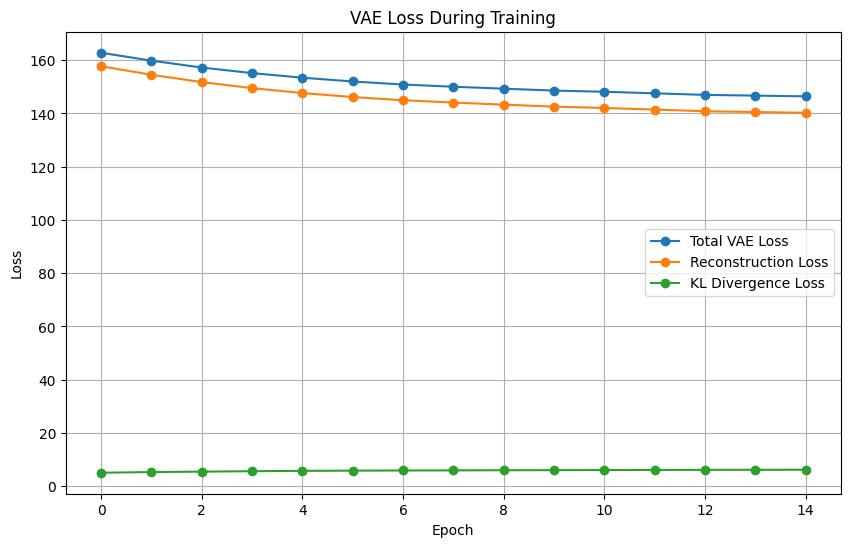

In [37]:
# STEP 12: VAE Loss Visualization

plt.figure(figsize=(10, 6))

plt.plot(
    total_loss_history,
    marker="o",
    label="Total VAE Loss"
)

plt.plot(
    reconstruction_loss_history,
    marker="o",
    label="Reconstruction Loss"
)

plt.plot(
    kl_loss_history,
    marker="o",
    label="KL Divergence Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss During Training")
plt.legend()
plt.grid(True)

plt.show()

#13. Reconstruction TesT :

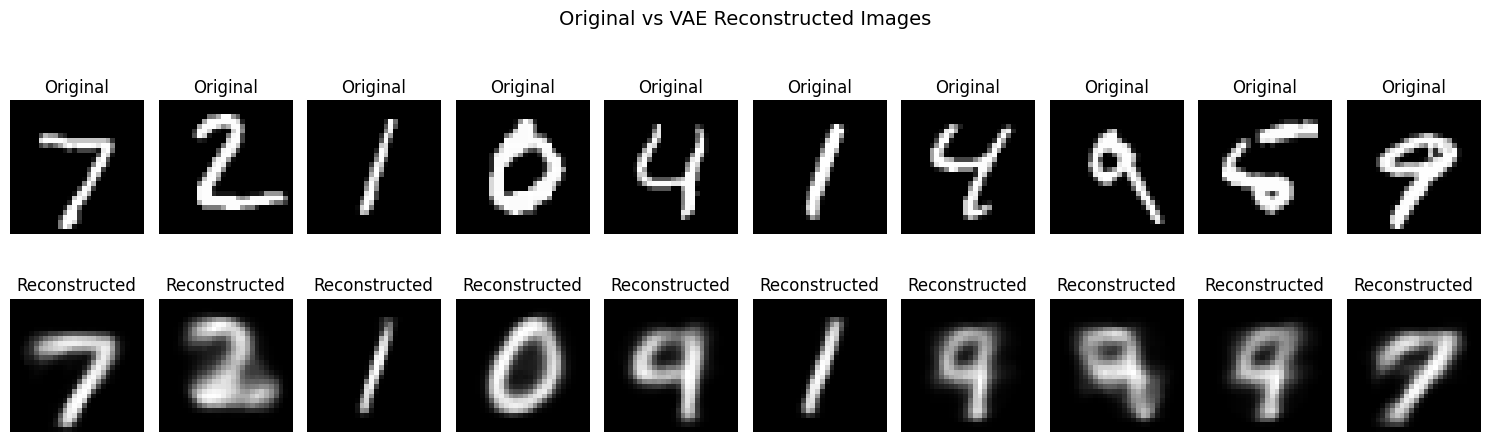

In [38]:
# STEP 13: Original vs Reconstructed Images

num_images = 10

# Select test images
original_images = x_test[:num_images]

# Encode
z_mean, z_log_var, z = vae_encoder(
    original_images,
    training=False
)

# Decode
reconstructed_images = vae_decoder(
    z,
    training=False
)

# Display
plt.figure(figsize=(15, 5))

for i in range(num_images):

    # Original image
    plt.subplot(2, num_images, i + 1)

    plt.imshow(
        original_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(
        2,
        num_images,
        num_images + i + 1
    )

    plt.imshow(
        reconstructed_images[i].numpy().squeeze(),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle(
    "Original vs VAE Reconstructed Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

#14. VAE LatenT Space :  

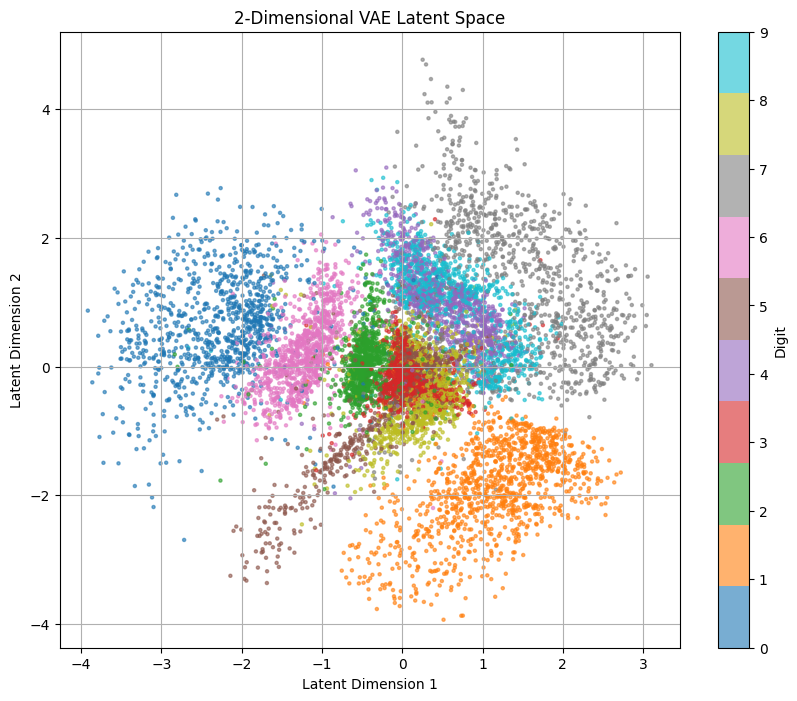

In [39]:


z_mean_all, z_log_var_all, z_all = vae_encoder(
    x_test,
    training=False
)

z_mean_all = z_mean_all.numpy()

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title(
    "2-Dimensional VAE Latent Space"
)

plt.grid(True)
plt.show()

#15. Generation Of Images directly from LatenT space

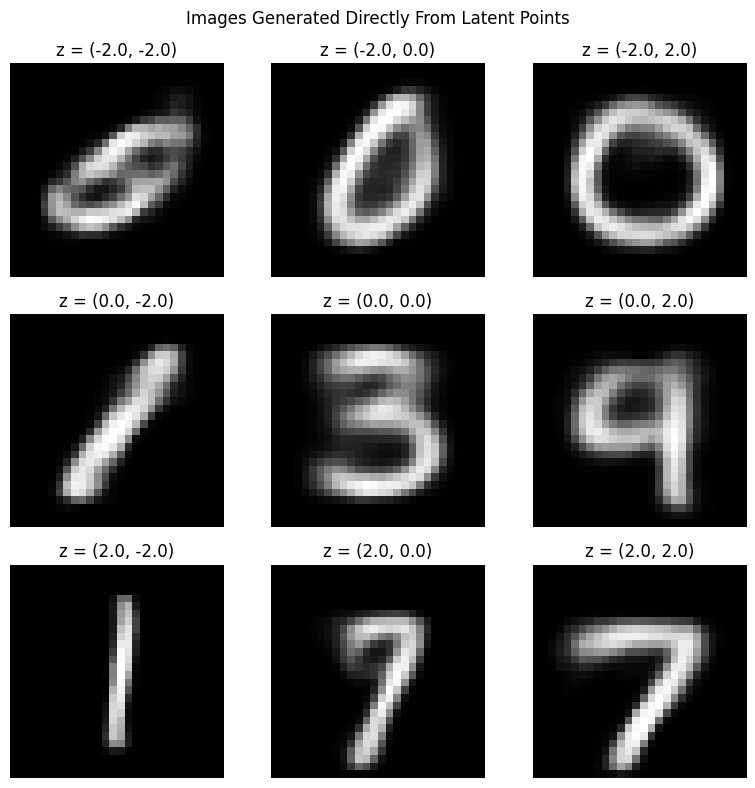

In [42]:
# STEP 15: Generate images directly from latent points

latent_points = np.array([
    [-2.0, -2.0],
    [-2.0,  0.0],
    [-2.0,  2.0],
    [ 0.0, -2.0],
    [ 0.0,  0.0],
    [ 0.0,  2.0],
    [ 2.0, -2.0],
    [ 2.0,  0.0],
    [ 2.0,  2.0]
], dtype="float32")

generated_images = vae_decoder.predict(
    latent_points,
    verbose=0
)

plt.figure(figsize=(8, 8))

for i in range(len(latent_points)):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"z = ({latent_points[i,0]:.1f}, "
        f"{latent_points[i,1]:.1f})"
    )

    plt.axis("off")

plt.suptitle(
    "Images Generated Directly From Latent Points"
)

plt.tight_layout()
plt.show()

#16. LatenT Space TransformaTion :

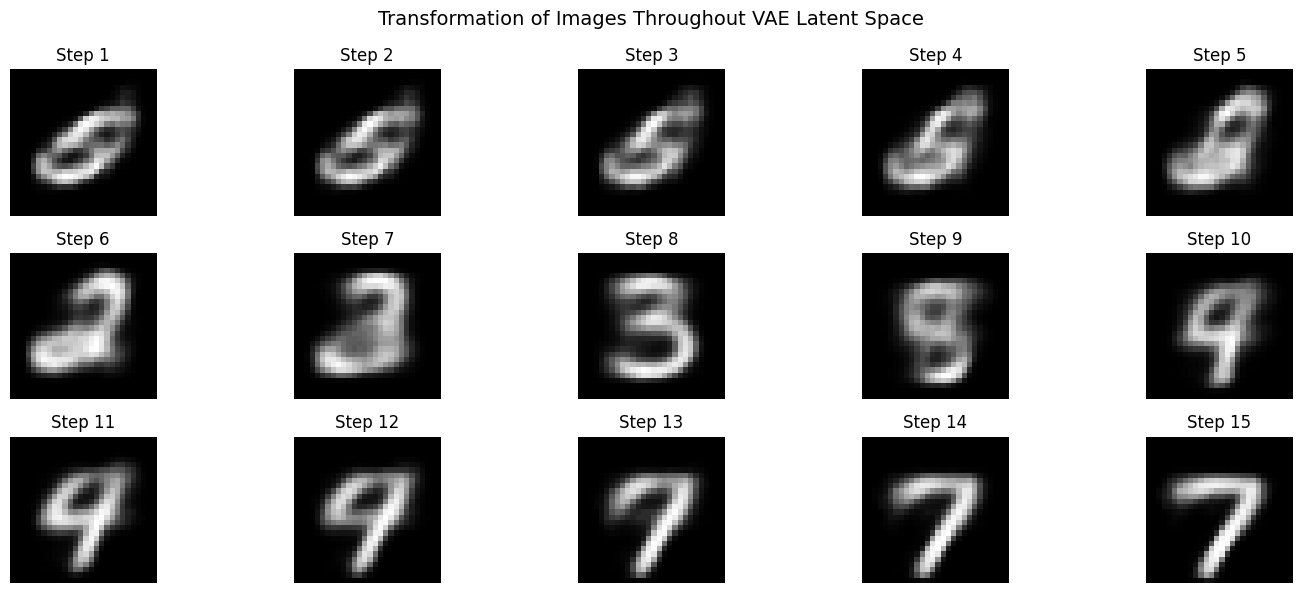

In [44]:
start_point = np.array([-2.0, -2.0])
end_point = np.array([2.0, 2.0])

num_steps = 15

# Generate intermediate latent points
latent_path = np.linspace(
    start_point,
    end_point,
    num_steps
).astype("float32")

# Generate images
transformed_images = vae_decoder.predict(
    latent_path,
    verbose=0
)

# Display transformation
plt.figure(figsize=(15, 6))

for i in range(num_steps):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        transformed_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Step {i + 1}"
    )

    plt.axis("off")

plt.suptitle(
    "Transformation of Images Throughout VAE Latent Space",
    fontsize=14
)

plt.tight_layout()
plt.show()

#17. Generate images from Extreme LatenT Space :

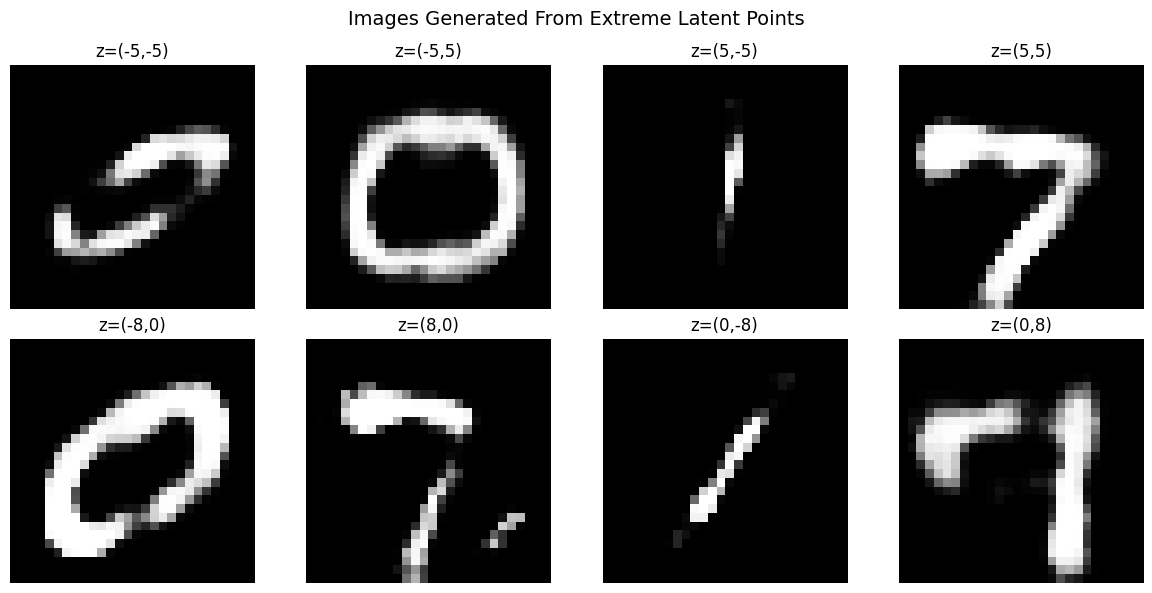

In [45]:

extreme_points = np.array([
    [-5.0, -5.0],
    [-5.0,  5.0],
    [ 5.0, -5.0],
    [ 5.0,  5.0],
    [-8.0,  0.0],
    [ 8.0,  0.0],
    [ 0.0, -8.0],
    [ 0.0,  8.0]
], dtype="float32")

extreme_images = vae_decoder.predict(
    extreme_points,
    verbose=0
)

plt.figure(figsize=(12, 6))

for i in range(len(extreme_points)):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        extreme_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"z=({extreme_points[i,0]:.0f},"
        f"{extreme_points[i,1]:.0f})"
    )

    plt.axis("off")

plt.suptitle(
    "Images Generated From Extreme Latent Points",
    fontsize=14
)

plt.tight_layout()
plt.show()

#18. CompleTe latenT-Space Image Grid :

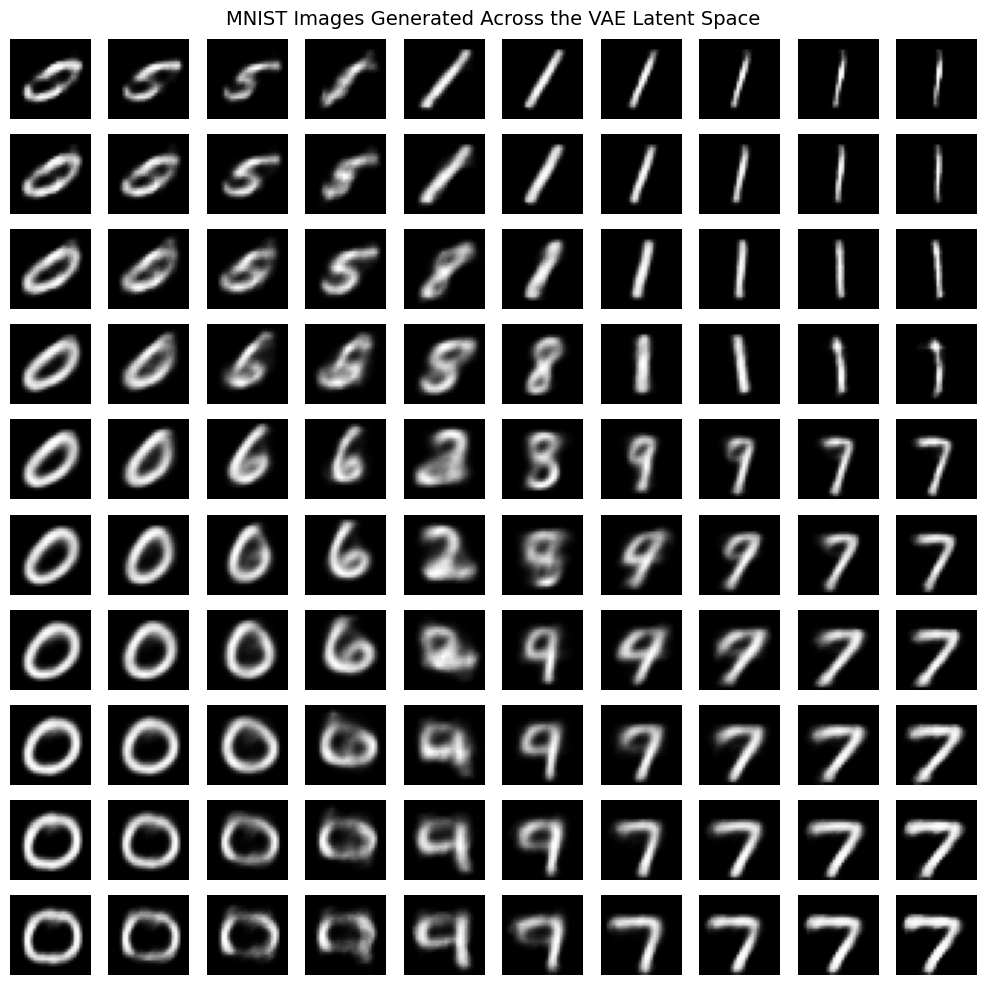

In [46]:
grid_size = 10

z1 = np.linspace(-3, 3, grid_size)
z2 = np.linspace(-3, 3, grid_size)

grid_points = []

for y in z2:
    for x in z1:
        grid_points.append([x, y])

grid_points = np.array(
    grid_points,
    dtype="float32"
)

grid_images = vae_decoder.predict(
    grid_points,
    verbose=0
)

plt.figure(figsize=(10, 10))

for i in range(grid_size * grid_size):

    plt.subplot(
        grid_size,
        grid_size,
        i + 1
    )

    plt.imshow(
        grid_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "MNIST Images Generated Across the VAE Latent Space",
    fontsize=14
)

plt.tight_layout()
plt.show()

#OBSERVAtiON :

1. Do similar digits form clusters?

    Yes. Similar digits tend to form groups or clusters in the 2-dimensional latent space because the VAE learns similar representations for visually similar handwritten digits.

2. Are the clusters clearly separated?

    The clusters are partially separated, although some overlap can be observed between digits with similar shapes. This indicates that the VAE has learned meaningful but not perfectly distinct representations.

3. How do generated digits change when moving gradually through the latent space?

    As we move gradually from one latent point to another, the generated digits progressively change in their shape, structure, and appearance rather than changing abruptly.

4. Does the transition between generated images appear smooth?

    Yes. The transition generally appears smooth and continuous, demonstrating that the VAE has learned a structured latent space in which nearby latent points can produce visually related images.